## Домашка 1
#### *«Великаны — как луковицы. Лук многослоен! Я тоже! Слой за слоем. Ты усёк? Мы многослойные!» — Шрек*

Эта домашка про декомпозицию и срезы. За неё можно получить максимум 6 баллов. 

**Дедлайны**  
Мягкий дедлайн: 20.09.2026 23:59 по МСК.   
Жесткий дедлайн: 27.09.2026 23:59 по МСК.  

Штраф за сдачу после мягкого дедлайна: –20% от набранного балла.   
После жесткого дедлайна работы не принимаются.   

**Правила сдачи**   
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.    

**Использование ИИ**
- Использование генеративных моделей для написания кода допустимо при следующих условиях: сгенерированный фрагмент прочитан, адаптирован под условие задачи и данные, вы способны объяснить каждую его строку. Решение, полученное путем передачи модели формулировки задания целиком и прямого копирования ответа в ячейку ноутбука без содержательной переработки, оценивается в 0 баллов за это задание.
- Ответы на текстовые вопросы (описание поведения графика, интерпретация метрики, формулировка гипотез и т.п.) должны быть написаны вами самостоятельно в markdown-ячейках. Использование генеративных моделей для ответа на текстовые вопросы приводит к аннулированию всей работы, а не отдельного задания: интерпретация результатов — главный проверяемый в курсе навык, передача ее ИИ лишает нас возможности оценить, насколько хорошо вы усвоили материал.
- Если генеративная модель использовалась при решении, в конце ноутбука в отдельной markdown-ячейке укажите: номера заданий, при работе над которыми она применялась, использованную модель (с версией) и текст промтов. При обоснованном подозрении на использование ИИ, не отраженное в этом разделе, работа аннулируется целиком независимо от того, к какой части заданий относится подозрение.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в ведомости на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_1). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. Ссылку на PR продублируйте в форме сдачи (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса).

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.

Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_1_data.zip)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-dark')
%matplotlib inline

### Case Study. Что-то пошло не так в маркетплейсе 🛒

**Легенда**  
Вы работаете продуктовым аналитиком в маркетплейсе. Ваша команда отвечает за функционал корзины — точки входа, дизайн и функционал самой корзины, путь пользователя с момента добавления товара в корзину и до оформления покупки. 

Компания — стартап без системы автоматического мониторинга. Поэтому последние 14 дней, пока вы были в отпуске, никто не следил за метриками корзины. 

Вы отлично отдохнули и в первый же день после каникул рвётесь в бой. Наливаете чашку кофе, открываете ноутбук и проверяете, что творилось в ваше отсутствие.

In [3]:
df = pd.read_parquet('data/hw_1_marketplace_data.parquet')

In [4]:
df.head()

,user_id,session_id,event_ts,platform,app_version,region,channel,category,event,product_id,price,quantity
0,30,1094418511,2025-04-01 19:49:57,Desktop,web,siberia,ads_search,None,search,NaN,NaN,NaN
1,30,1094418511,2025-04-01 20:02:23,Desktop,web,siberia,ads_search,electronics,view_item,123443.0,NaN,NaN
2,30,1094418511,2025-04-01 20:22:53,Desktop,web,siberia,ads_search,fashion,view_item,162950.0,NaN,NaN
3,30,1094418511,2025-04-01 20:40:57,Desktop,web,siberia,ads_search,home,view_item,199979.0,NaN,NaN
4,30,1094418511,2025-04-01 20:41:07,Desktop,web,siberia,ads_search,home,add_to_cart,199979.0,NaN,NaN


Описание данных

- user_id — уникальный идентификатор пользователя
- session_id — уникальный идентификатор сессии
- event_ts — таймстемп событий
- platform — платформа, с которой пришло событие
- app_version — версия приложения (существует только для iOS и Android, для остальных платформ приходят значения-заглушки)
- region — регион пользователя
- category — канал, с которого пришел пользователь
- category — категория товаров, которой принадлежит ивент
- event — событие, совершенное пользователем
- product_id — идентификатор товара для событий над товарами
- price — цена товара, ивент приходит только для события покупки
- quantity — количество товаров, ивент приходит только для события покупки

#### **1. Детекция проблемы — 1 балл**

1) Посчитайте подневные конверсии: из просмотра в покупку, из просмотра в добавление в корзину, из добавления в корзину — в покупку.
2) Визуализируйте полученную динамику. 
3) Опишите, что вы видите на графике: когда и в каких метриках началось падение? есть ли устойчивый тренд?

*К подсчёту конверсий можно подойти разными способами — считать их по событиям, сессиям или уникальным юзерам. В нашей задаче будем считать по сессиям.*

In [33]:
# your code is here

df['event_day']=df['event_ts'].dt.normalize()

In [34]:
conversion=df.pivot_table(index='event_day', columns='event', values='session_id', aggfunc='nunique') #формирую таблицу для расчета конверсий по сессиям

In [35]:
conversion.head(2)

event,add_to_cart,add_to_favorites,purchase,remove_from_cart,search,view_item
event_day,,,,,,
2025-04-01,633,590,209,50,1197,1949
2025-04-02,677,614,208,57,1263,2092


In [8]:
conversion['view_item_to_purchase']=conversion['purchase']*100/conversion['view_item'] #конверсия из просмотра в покупку
conversion['view_item_to_add_to_cart']=conversion['add_to_cart']*100/conversion['view_item'] #конверсия из просмотра в добавление в корзину
conversion['add_to_cart_to_purchase']=conversion['purchase']*100/conversion['add_to_cart'] #конверсия из добавления в корзину в покупку
conversion.reset_index(inplace=True)

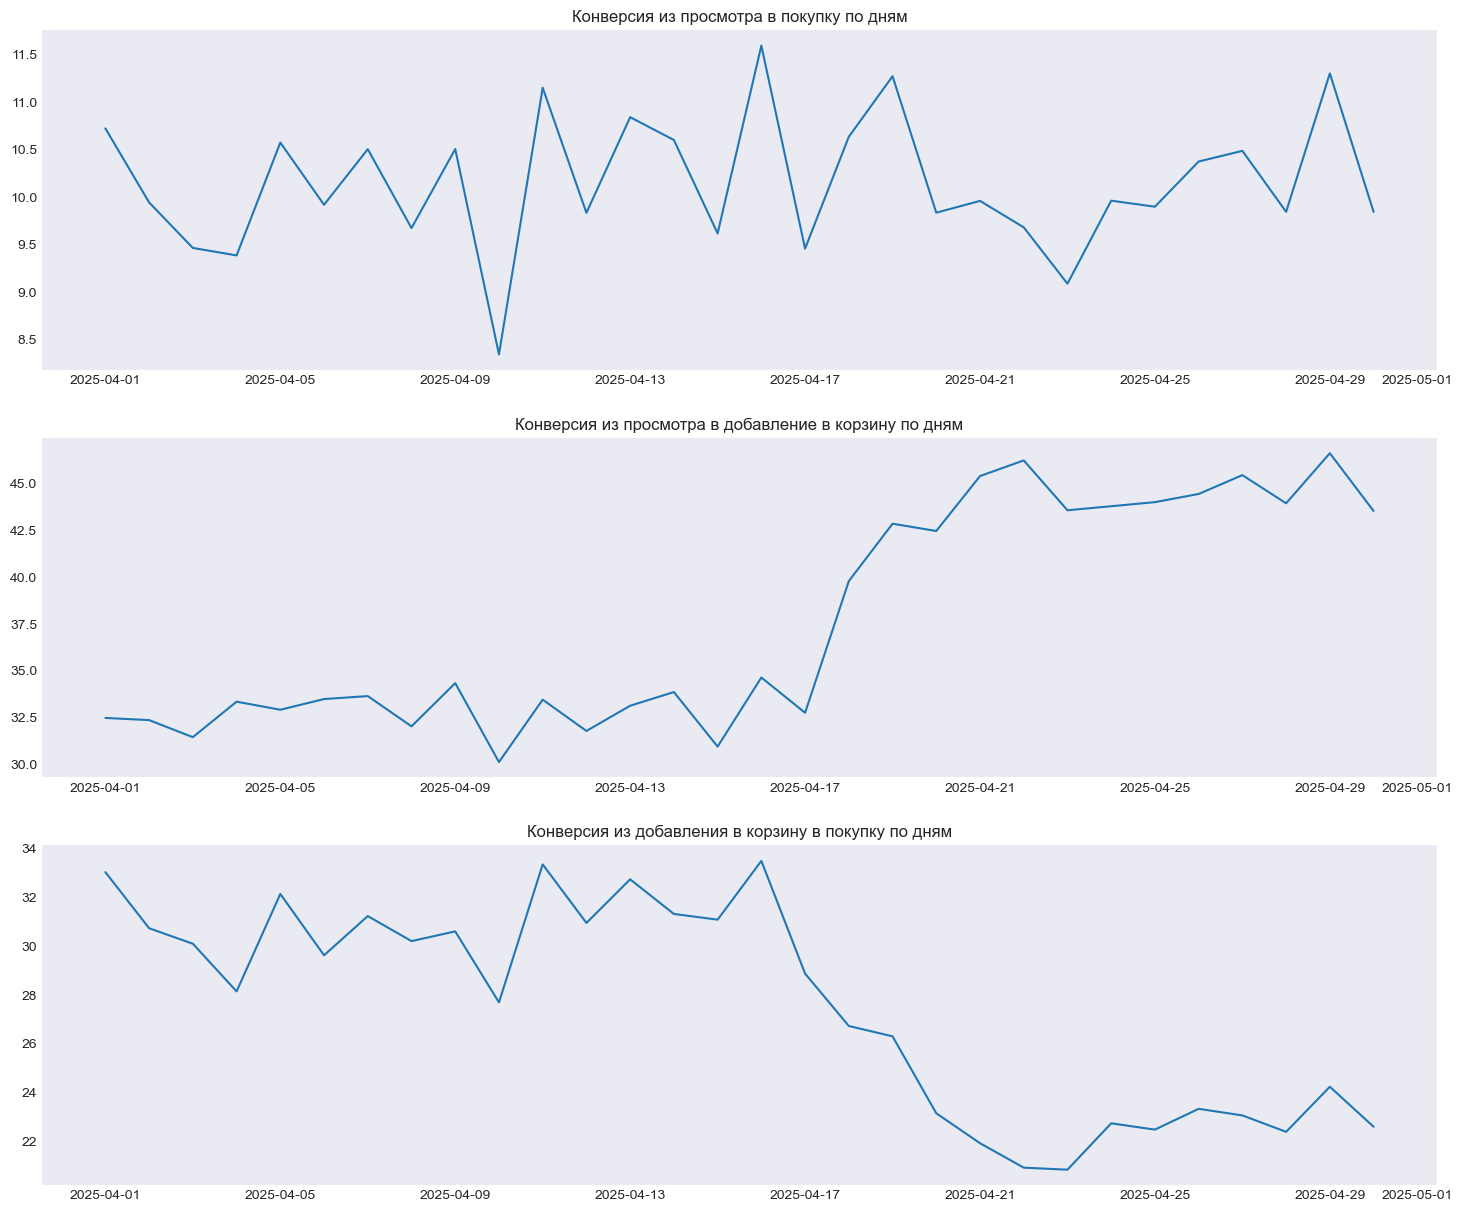

In [9]:
fig, ax = plt.subplots(3,1, figsize=(18,15))

ax[0].plot(conversion['event_day'], conversion['view_item_to_purchase'])
ax[0].set_title('Конверсия из просмотра в покупку по дням')
ax[1].plot(conversion['event_day'], conversion['view_item_to_add_to_cart'])
ax[1].set_title('Конверсия из просмотра в добавление в корзину по дням')
ax[2].plot(conversion['event_day'], conversion['add_to_cart_to_purchase'])
ax[2].set_title('Конверсия из добавления в корзину в покупку по дням')
plt.show()

**Выводы: на графике 'Конверсия из добавления в корзину в покупку по дням' с 2025-04-17 числа наблюдается падение метрики, при этом у метрики конверсии из просмотра в добавление в корзину по дням наблюдается симметричный рост. Видимо, что-то произошло с количеством добавлений в корзину, потому как в формуле второй метрики число добавлений в корзину находится в числителе и его увеличение приведет к росту метрики. А в формуле третьей метрики число добавлений стоит в знаменателе и его рост снижает метрику. 
Ответить уверенно насчет тренда мне сложно, мы еще не проходили теорию временных рядов и рассматриваемый период совсем небольшой - меньше месяца. Но учитывая, что две метрики после 2025-04-17 числа не вернулись на прежний уровень и не было заметных колебаний до прежнего уровня, то могу предположить, что как минимум, наметился новый тренд.**

#### **2. Проверка абсолютных и средних значений — 1 балл**

1) Постройте графики дневной динамики абсолютных значений, из которых рассчитаны конверсии выше.
2) Рассчитайте и визуализируйте среднее число событий (именно событий, не сессий), из которых рассчитаны конверсии, на пользователя. 
3) На каком этапе воронки появилась проблема?

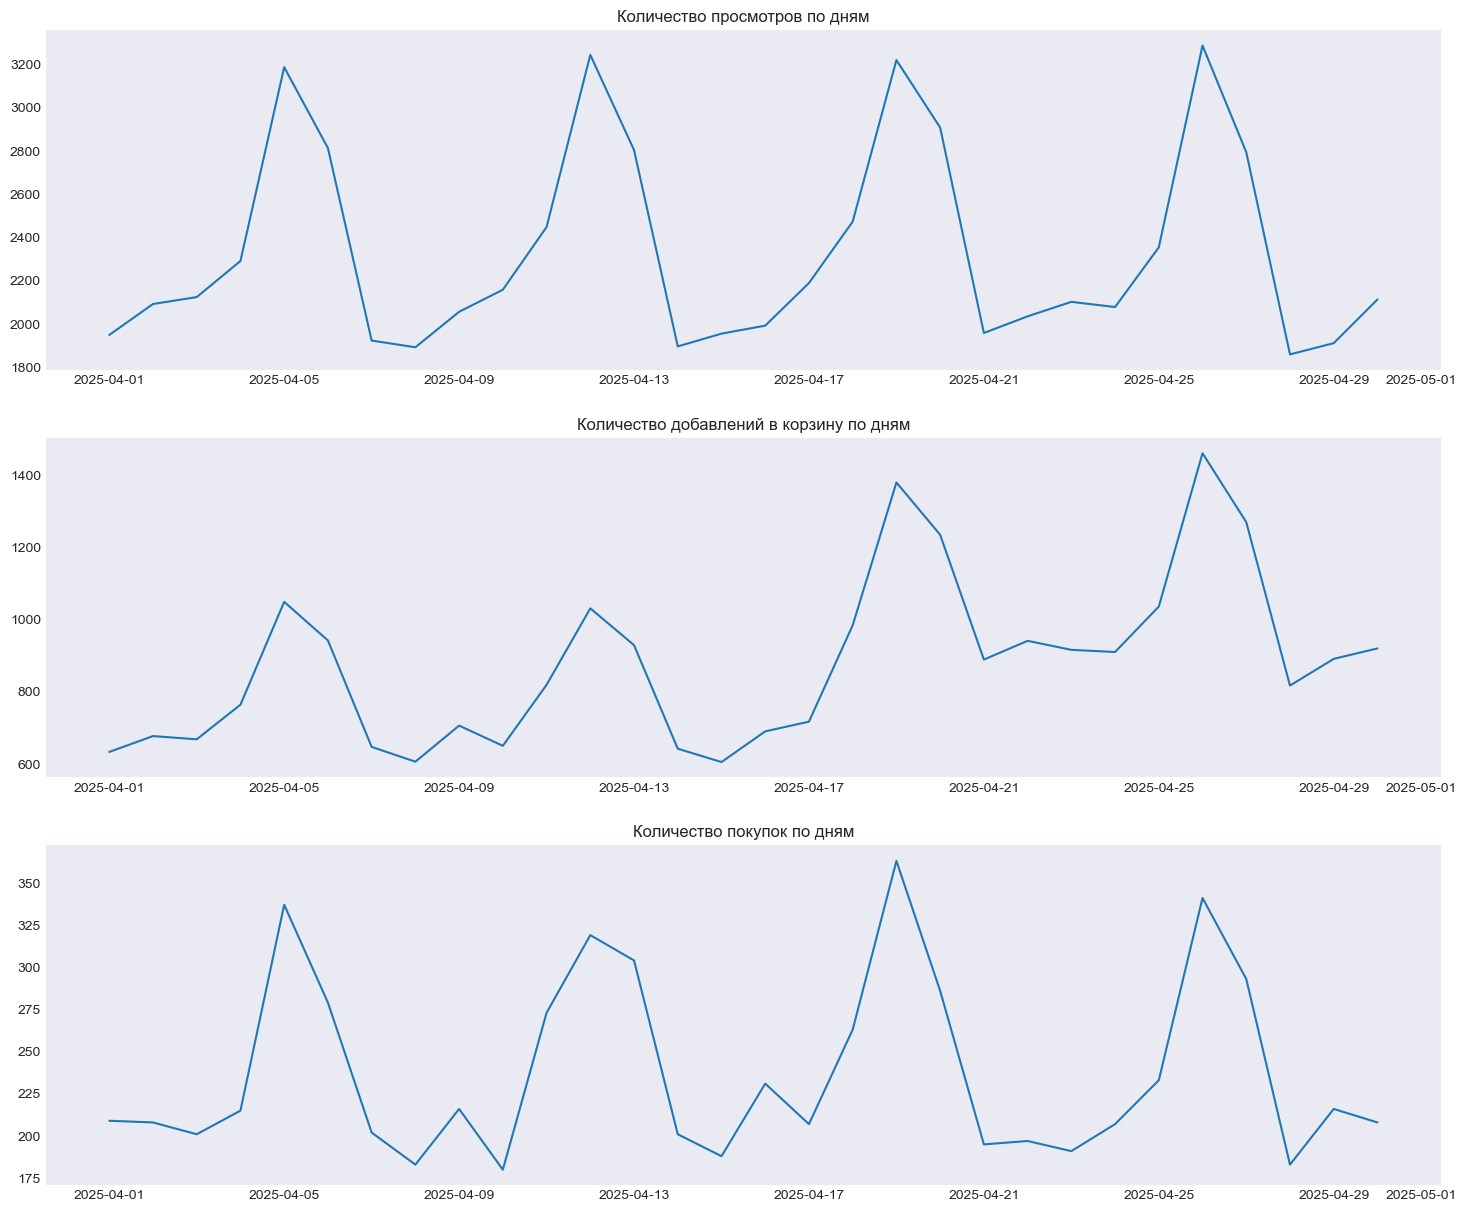

In [10]:
# your code is here

fig, ax = plt.subplots(3,1, figsize=(18,15))

ax[0].plot(conversion['event_day'], conversion['view_item'])
ax[0].set_title('Количество просмотров по дням')
ax[1].plot(conversion['event_day'], conversion['add_to_cart'])
ax[1].set_title('Количество добавлений в корзину по дням')
ax[2].plot(conversion['event_day'], conversion['purchase'])
ax[2].set_title('Количество покупок по дням')
plt.show()

**Видно, что количество добавлений в корзину после 17.04 подросло, график в своей нижней точки не достигает прежнего минимального значения. В целом заметен возрастающий тренд.**

In [36]:
 #среднее количество событий на пользователя

event_per_user=df.query('event in ["add_to_cart", "purchase", "view_item"]').groupby(['event_day', 'event'], as_index=False).agg(event_count=('event', 'size'), users=('user_id', 'nunique'))
event_per_user['avg_events_per_user']=(event_per_user['event_count']/event_per_user['users']).round(2)
event_per_user.head()

,event_day,event,event_count,users,avg_events_per_user
0,2025-04-01,add_to_cart,729,567,1.29
1,2025-04-01,purchase,218,204,1.07
2,2025-04-01,view_item,4512,1376,3.28
3,2025-04-02,add_to_cart,763,585,1.30
4,2025-04-02,purchase,213,199,1.07


In [37]:
import seaborn as sns

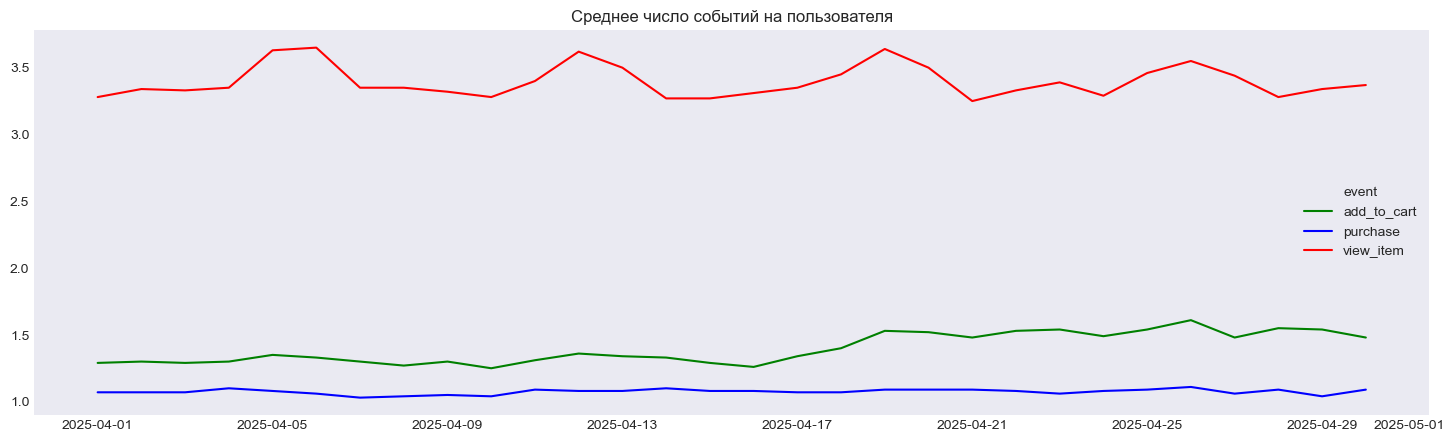

In [38]:
plt.figure(figsize=(18,5))
sns.lineplot(data=event_per_user, x='event_day', y='avg_events_per_user', hue='event', palette={'add_to_cart':'green', 'purchase':'blue', 'view_item':'red'})
plt.xlabel('')
plt.ylabel('')
plt.title('Среднее число событий на пользователя')
plt.show()

**Проблема на этапе добавления продукта в корзину: на текущем графике также подтверждается, что среднее количество событий после 17.04 выросло.**

#### **3. Базовые срезы — 1 балл**
1. Постройте динамику события, среднее значение которого подскочило, в разрезе:
- платформ,
- регионов,
- источников трафика,
- категорий товаров.

2. Есть ли выделяющийся срез?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

In [63]:
def calculate_avg_events(df, feature, platform=None, app_version=None):
    filtered_df=df.query('event=="add_to_cart"')

    if platform is not None:
        filtered_df=filtered_df.query('platform==@platform')

    if app_version is not None:
            filtered_df=filtered_df.query('app_version==@app_version"')

    result=filtered_df.groupby(['event_day', feature], as_index=False).agg(event_count=(feature, 'size'), users=('user_id', 'nunique'))
    result['avg_events_per_user']=(result['event_count']/result['users']).round(2)

    return result

In [64]:
# your code is here

#динамика добавления в корзину в разрезе платформ:
add_to_cart_per_platform=calculate_avg_events(df, 'platform')

add_to_cart_per_platform.head()

,event_day,platform,event_count,users,avg_events_per_user
0,2025-04-01,Android,410,315,1.30
1,2025-04-01,Desktop,113,88,1.28
2,2025-04-01,Mobile,53,42,1.26
3,2025-04-01,iOS,153,122,1.25
4,2025-04-02,Android,394,297,1.33


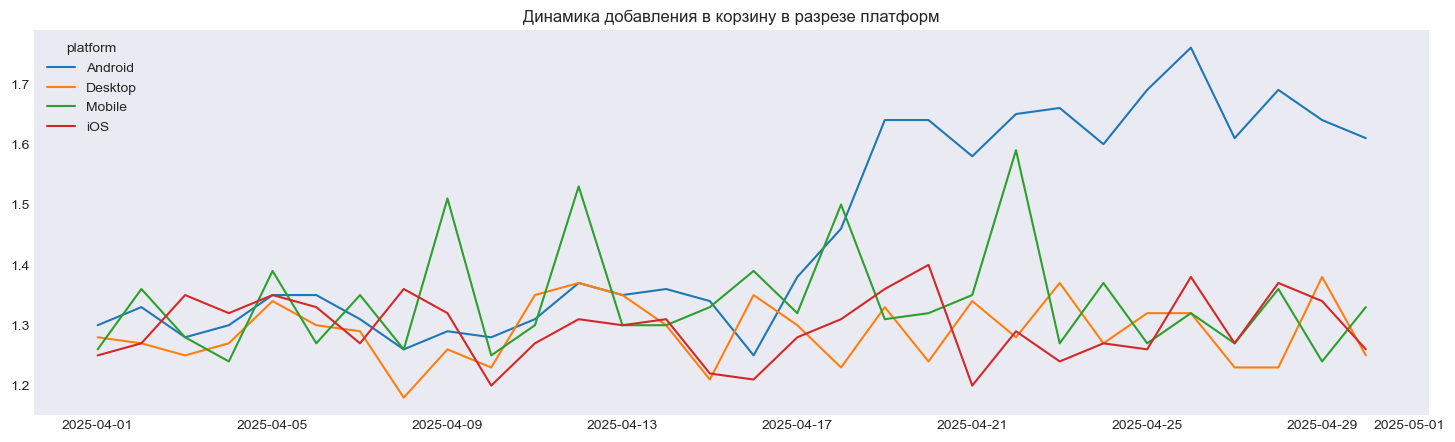

In [65]:
plt.figure(figsize=(18,5))
sns.lineplot(data=add_to_cart_per_platform, x='event_day', y='avg_events_per_user', hue='platform')
plt.xlabel('')
plt.ylabel('')
plt.title('Динамика добавления в корзину в разрезе платформ')
plt.show()

**На этом графике заметно выделяется график для Android. Он также вырос после 17.04**

In [66]:
#динамика добавления в корзину в разрезе регионов:

add_to_cart_per_region=calculate_avg_events(df, 'region')
add_to_cart_per_region=add_to_cart_per_region.pivot(index='event_day', columns='region', values='avg_events_per_user')
add_to_cart_per_region.head()

region,central,far_east,leningrad_oblast,moscow_city,moscow_oblast,siberia,south,spb_city,urals,volga
event_day,,,,,,,,,,
2025-04-01,1.37,1.30,1.40,1.33,1.21,1.31,1.24,1.14,1.21,1.28
2025-04-02,1.30,1.30,1.33,1.34,1.30,1.23,1.45,1.24,1.30,1.24
2025-04-03,1.24,1.20,1.76,1.26,1.36,1.33,1.22,1.37,1.28,1.29
2025-04-04,1.28,1.39,1.17,1.30,1.22,1.29,1.22,1.17,1.45,1.37
2025-04-05,1.36,1.20,1.21,1.37,1.44,1.30,1.31,1.34,1.39,1.33


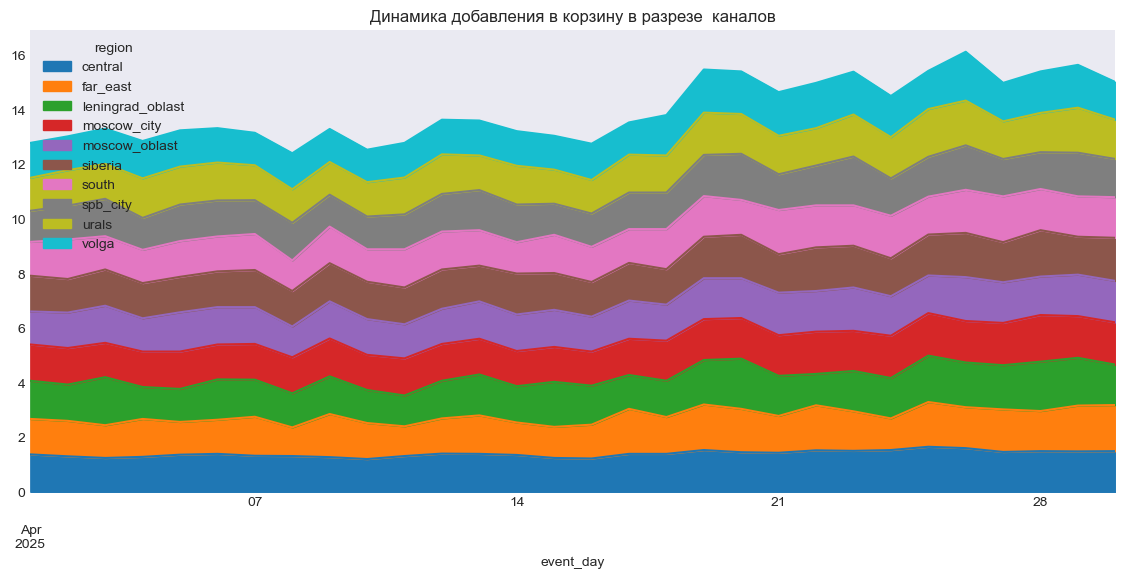

In [67]:
add_to_cart_per_region.plot.area(figsize=(14, 6))
plt.title('Динамика добавления в корзину в разрезе  каналов')
plt.show()

**В разрезе регионов не видно, чтобы кто-то существенно выделялся на фоне других, но в целом заметно, что уровень между 14 и 21 стал выше по всем регионам**

In [68]:
#динамика добавления в корзину в разрезе каналов:

add_to_cart_per_channel=calculate_avg_events(df, 'channel')
add_to_cart_per_channel=add_to_cart_per_channel.pivot(index='event_day', columns='channel', values='avg_events_per_user')
add_to_cart_per_channel.head()

channel,ads_search,ads_social,organic,referral
event_day,,,,
2025-04-01,1.30,1.25,1.30,1.23
2025-04-02,1.38,1.31,1.29,1.19
2025-04-03,1.24,1.29,1.31,1.32
2025-04-04,1.28,1.33,1.30,1.20
2025-04-05,1.34,1.39,1.35,1.21


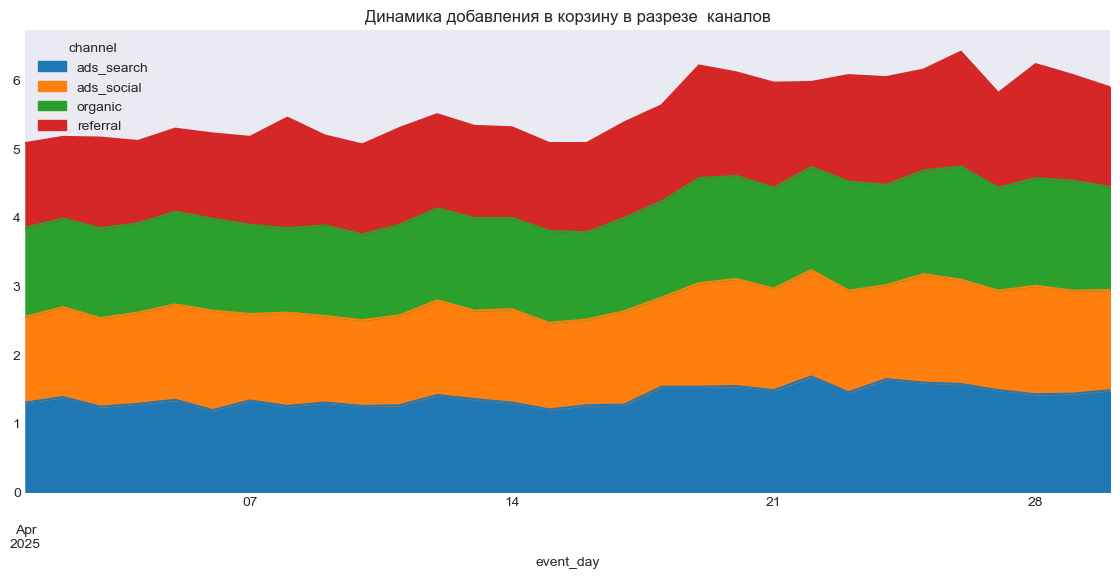

In [69]:
add_to_cart_per_channel.plot.area(figsize=(14, 6))
plt.title('Динамика добавления в корзину в разрезе  каналов')
plt.show()

**Ни один канал не выделяется на фоне остальных, но общий уровень действия также подрос.**

In [70]:
#динамика добавления в корзину в разрезе категории:

add_to_cart_per_category=calculate_avg_events(df,'category')
add_to_cart_per_category=add_to_cart_per_category.pivot(index='event_day', columns='category', values='avg_events_per_user')
add_to_cart_per_category.head()

category,beauty,electronics,fashion,garden,home
event_day,,,,,
2025-04-01,1.04,1.06,1.14,1.00,1.02
2025-04-02,1.05,1.07,1.12,1.04,1.06
2025-04-03,1.09,1.06,1.09,1.00,1.05
2025-04-04,1.05,1.05,1.11,1.00,1.09
2025-04-05,1.08,1.05,1.11,1.01,1.08


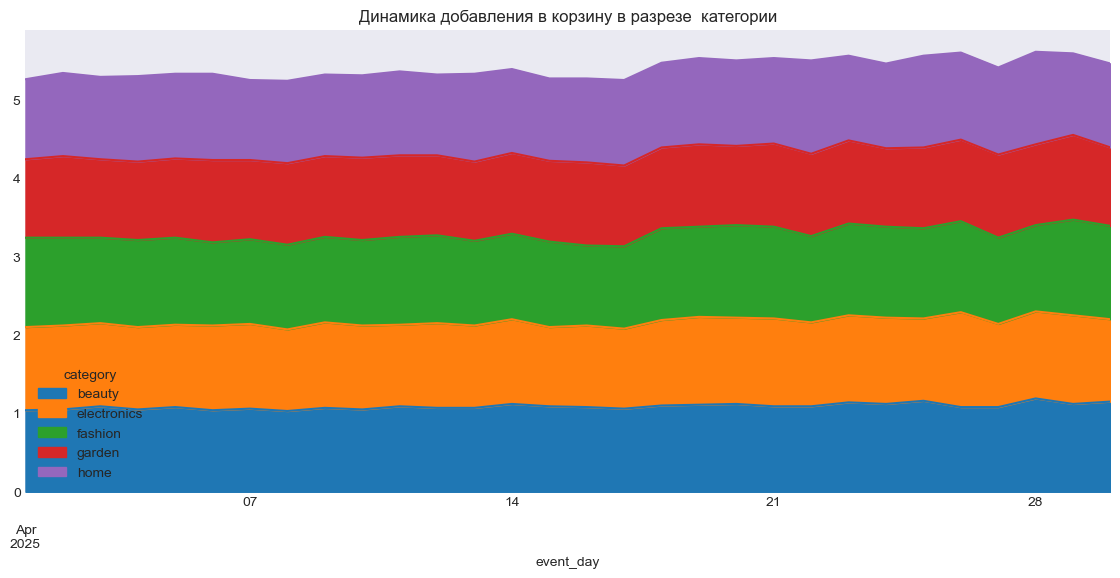

In [71]:
add_to_cart_per_category.plot.area(figsize=(14, 6))
plt.title('Динамика добавления в корзину в разрезе  категории')
plt.show()

**В разрезе категорий проблема не видно.**

#### **4. Детальные срезы — 1 балл**
1. Постройте динамику события для iOS и Android с разложением по версиям приложения.
2. Помогло ли это локализовать проблему?

*В этом пункте в качестве события продолжаем смотреть метрику среднего на пользователя*

In [78]:
# your code is here
#Динамика события 'add to cart' по всем версиям Android и iOS:
add_to_cart_Android=calculate_avg_events(df, 'app_version', platform='Android')
add_to_cart_iOS=calculate_avg_events(df, 'app_version', platform='iOS')

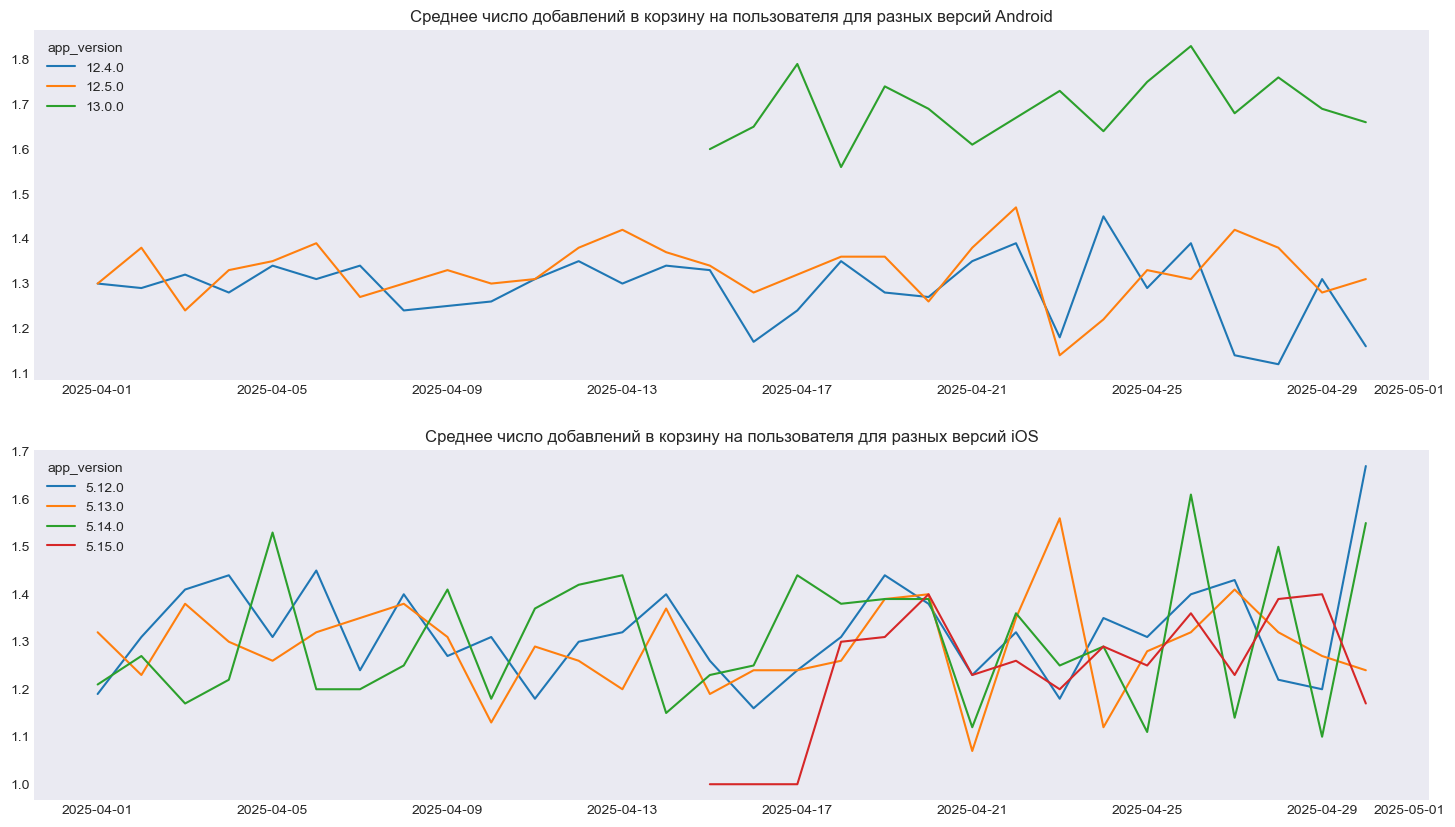

In [80]:
fig, ax = plt.subplots(2,1, figsize=(18,10))

sns.lineplot(data=add_to_cart_Android, x='event_day', y='avg_events_per_user', hue='app_version', ax=ax[0])
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Среднее число добавлений в корзину на пользователя для разных версий Android')

sns.lineplot(data=add_to_cart_iOS, x='event_day', y='avg_events_per_user', hue='app_version', ax=ax[1])
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_title('Среднее число добавлений в корзину на пользователя для разных версий iOS')


plt.show()

**На графике для Android заметно выделяется график версии 13.0.0 - для нее среднее количество добавлений продукта в корзину на пользователя выше, чем в остальных версиях.**

#### **5. Поиск причин — 1 балл**
1. Для проблемной платформы постройте динамику ВСЕХ событий в разрезе версий приложения.
2. Сформулируйте гипотезу, что именно могло пойти не так в новом релизе? Может быть, пользователи стали заменять один функционал другим?

*В этом пункте в качестве событий продолжаем смотреть метрику среднего на пользователя*

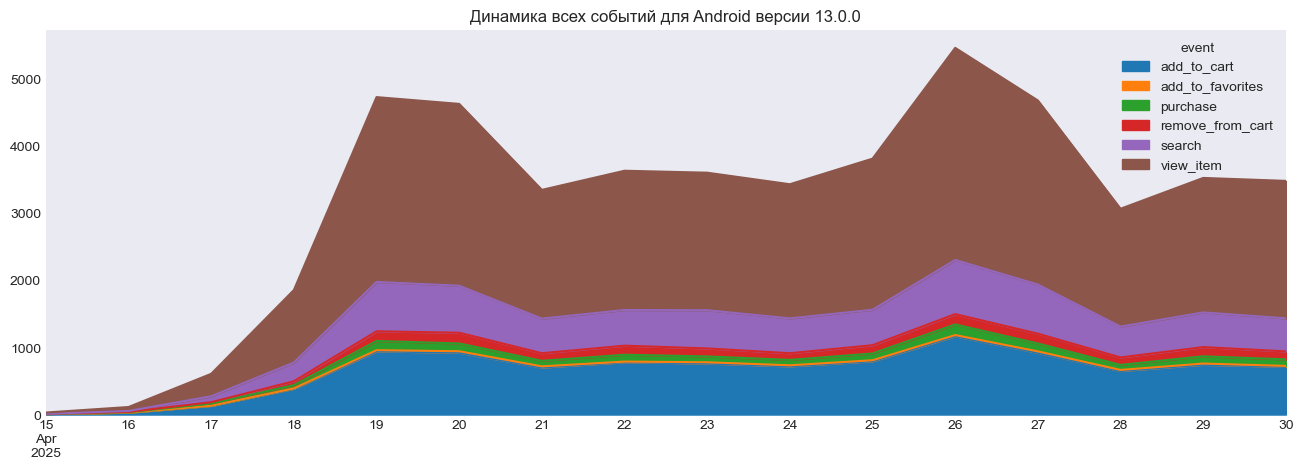

In [81]:
# your code is here

#динамика всех событий для проблемной версии приложения на Android:

Android_13=df.query('platform=="Android" and app_version=="13.0.0"').pivot_table(index='event_day', columns='event', values='user_id', aggfunc='size').fillna(0)
Android_13.plot.area(figsize=(16,5))
plt.xlabel('')
plt.title('Динамика всех событий для Android версии 13.0.0')
plt.show()

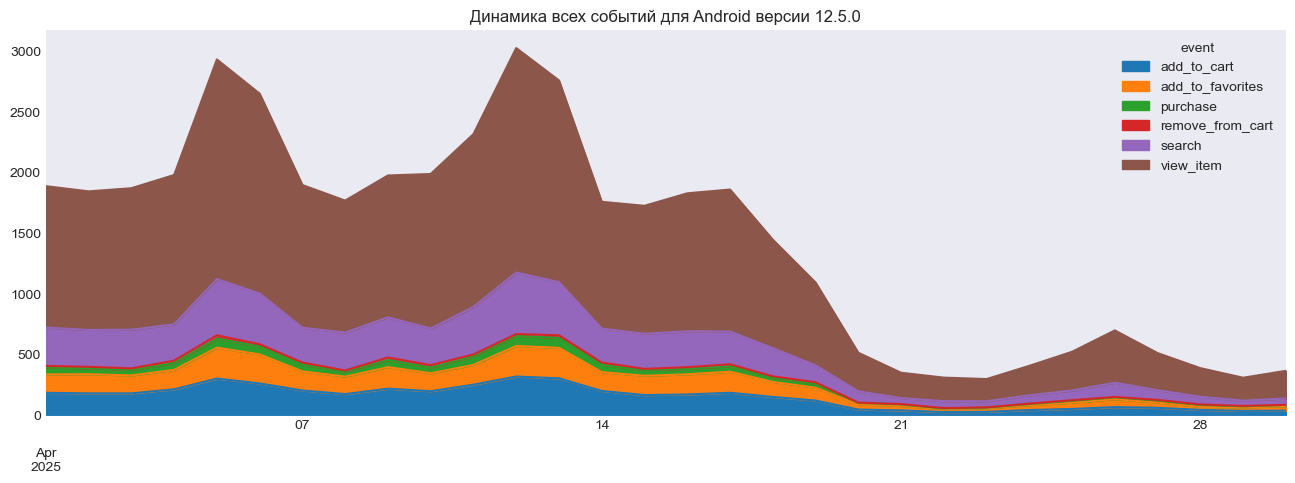

In [82]:
Android_12_5=df.query('platform=="Android" and app_version=="12.5.0"').pivot_table(index='event_day', columns='event', values='user_id', aggfunc='size').fillna(0)
Android_12_5.plot.area(figsize=(16,5))
plt.xlabel('')
plt.title('Динамика всех событий для Android версии 12.5.0')
plt.show()

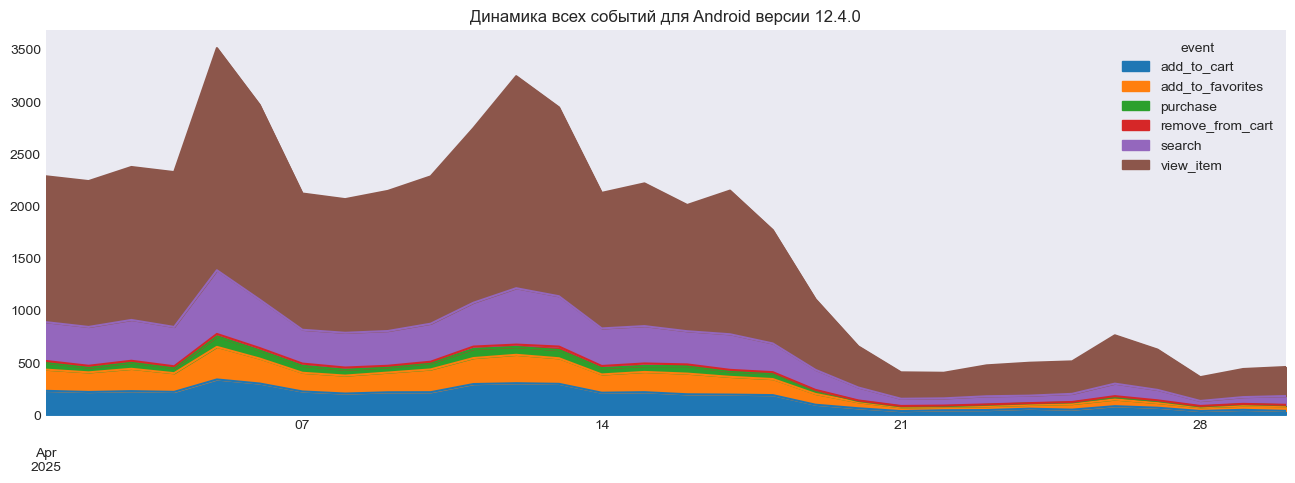

In [83]:
Android_12_4=df.query('platform=="Android" and app_version=="12.4.0"').pivot_table(index='event_day', columns='event', values='user_id', aggfunc='size').fillna(0)
Android_12_4.plot.area(figsize=(16,5))
plt.xlabel('')
plt.title('Динамика всех событий для Android версии 12.4.0')
plt.show()

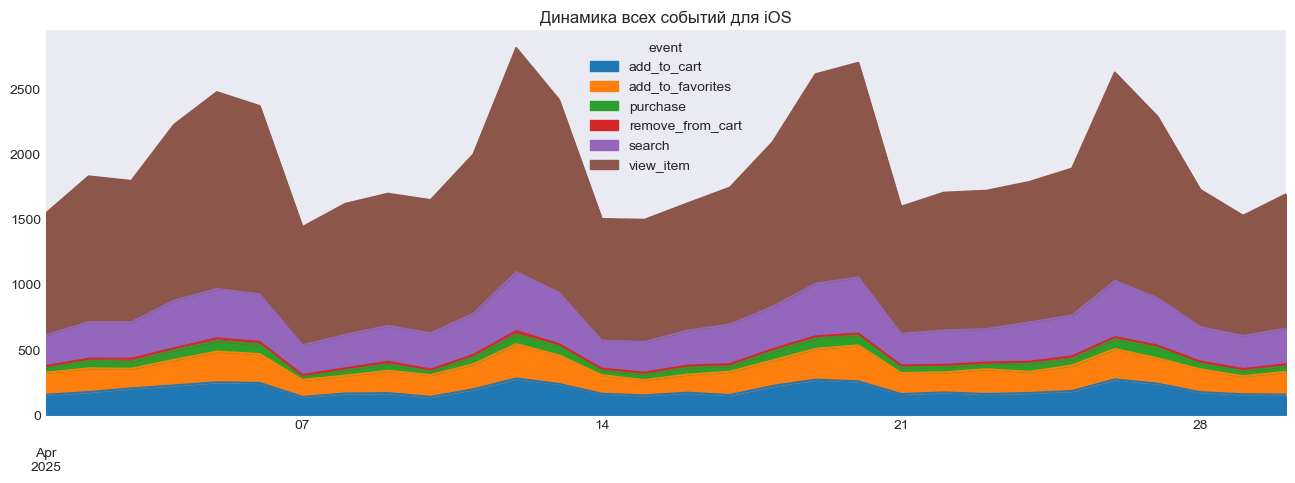

In [84]:
#динамика всех событий для iOS: 

iOS=df.query('platform=="iOS"').pivot_table(index='event_day', columns='event', values='user_id', aggfunc='size').fillna(0)
iOS.plot.area(figsize=(16,5))
plt.xlabel('')
plt.title('Динамика всех событий для iOS')
plt.show()

**На графике новой версии Android 13.0.0 видно, что действия 'add_to_favorites' меньше по высоте, чем на графиках других версий Android (в том числе для платформы iOS). Значит, по какой-то причине, на этой версии приложения пользователи перестали пользоваться этим функционалом. Возможно, что они стали замещать этот функционал добавлением товара в корзину с последующим удалением его при необходимости. Об этом также свидетельствует увеличение количества действий 'remove_from_cart' и 'add_to_cart' в новой версии Android по сравнению с действиями пользователями на других версиях. Если пользователи так резко перестали пользоваться функционалом 'add_to_favorites', скорее всего в этой версии есть техническая проблема, так как пропорции действий пользователей на других версиях сохраняются.**

#### **6. Новости для команды — 1 балл**

На основе проведённого расследования подготовьте сообщение для команды о том, что именно пошло не так.

**Коллеги, анализ действий пользователей за последние две недели показал, что пользователи версии Android 13.0.0 перестали помечать продукты как 'понравившиеся' (действие 'add_to_favorite'), а вместо него добавляют продукты сразу в корзину, тем самым обрушив метрики конверсий. При этом на платформе iOS и на других версиях платформы Android такой проблемы не замечено. Следовательно, в этой версии присутствует техническая ошибка в работе функционала. Предлагаю написать письмо разработчикам и дизайнерам для проверки и исправления функционал на стороне приложения.**